In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [3]:
data=pd.read_csv("credit_card_fraud_10k.csv")
data

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0
...,...,...,...,...,...,...,...,...,...,...
9995,9996,350.91,22,Food,0,0,99,4,37,0
9996,9997,410.04,5,Clothing,0,0,70,3,25,0
9997,9998,527.75,21,Electronics,0,0,44,2,45,0
9998,9999,91.20,2,Electronics,0,0,38,0,37,0


In [4]:
print("First 5 rows")
print(data.head())

First 5 rows
   transaction_id  amount  transaction_hour merchant_category  \
0               1   84.47                22       Electronics   
1               2  541.82                 3            Travel   
2               3  237.01                17           Grocery   
3               4  164.33                 4           Grocery   
4               5   30.53                15              Food   

   foreign_transaction  location_mismatch  device_trust_score  \
0                    0                  0                  66   
1                    1                  0                  87   
2                    0                  0                  49   
3                    0                  1                  72   
4                    0                  0                  79   

   velocity_last_24h  cardholder_age  is_fraud  
0                  3              40         0  
1                  1              64         0  
2                  1              61         0  
3        

In [5]:
print("\nMissing Values")
print(data.isnull().sum())


Missing Values
transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64


In [6]:
data.dropna(inplace=True)
data.drop_duplicates(inplace=True)

print("\nDataset shape:", data.shape)


Dataset shape: (10000, 10)


In [8]:
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  str    
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), str(1)
memory usage: 742.3 KB
None


In [16]:
le = LabelEncoder()
data["is_fraud"] = le.fit_transform(data["is_fraud"])

le_category = LabelEncoder()
data["merchant_category"] = le_category.fit_transform(data["merchant_category"])

In [19]:
x = data[[
    "amount",
    "transaction_hour",
    "merchant_category",
    "foreign_transaction",
    "location_mismatch",
    "device_trust_score",
    "velocity_last_24h",
    "cardholder_age"
]]

y = data["is_fraud"]

In [20]:
x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)    

In [21]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


In [22]:
model = LogisticRegression(
    class_weight='balanced',
    random_state=42\
)

model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [23]:
accuracy = accuracy_score(y_test,y_pred)

print("\nAccuracy Score")
print(round(accuracy * 100, 2), "%")

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))


Accuracy Score
95.85 %

Confusion Matrix
[[1887   83]
 [   0   30]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      1970
           1       0.27      1.00      0.42        30

    accuracy                           0.96      2000
   macro avg       0.63      0.98      0.70      2000
weighted avg       0.99      0.96      0.97      2000



In [24]:
amount = float(input("Enter Amount: "))
transaction_hour = int(input("Enter Transaction Hour (0-23): "))
merchant_category = input("Enter Merchant Category: ")
foreign_transaction = int(input("Foreign Transaction (0-No, 1-Yes): "))
location_mismatch = int(input("Location Mismatch (0-No, 1-Yes): "))
device_trust_score = int(input("Device Trust Score: "))
velocity_last_24h = int(input("Velocity Last 24 Hours: "))
cardholder_age = int(input("Enter Cardholder Age: "))

merchant_category = le_category.transform([merchant_category])[0]

user = [[
    amount,
    transaction_hour,
    merchant_category,
    foreign_transaction,
    location_mismatch,
    device_trust_score,
    velocity_last_24h,
    cardholder_age
]]

user_scaled = scaler.transform(user)

prediction = model.predict(user_scaled)
probability = model.predict_proba(user_scaled)

print("\nProbability")
print("Not Fraud :", round(probability[0][0] * 100, 2), "%")
print("Fraud     :", round(probability[0][1] * 100, 2), "%")

if prediction[0] == 1:
    print("\nRESULT : FRAUD")
else:
    print("\nRESULT : NOT FRAUD")
    

Enter Amount:  750
Enter Transaction Hour (0-23):  22
Enter Merchant Category:  Electronics
Foreign Transaction (0-No, 1-Yes):  1
Location Mismatch (0-No, 1-Yes):  0
Device Trust Score:  65
Velocity Last 24 Hours:  3
Enter Cardholder Age:  35


/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



Probability
Not Fraud : 97.9 %
Fraud     : 2.1 %

RESULT : NOT FRAUD


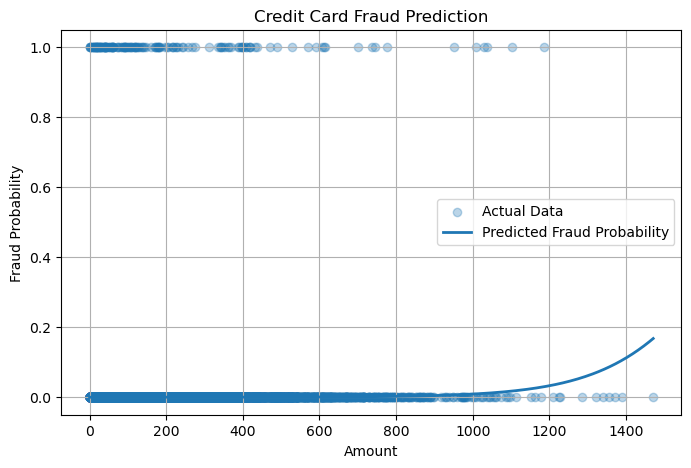

In [25]:
x_range = np.linspace(
    data["amount"].min(),
    data["amount"].max(),
    300
)

plot_data = pd.DataFrame({
    "amount": x_range,
    "transaction_hour": data["transaction_hour"].mean(),
    "merchant_category": data["merchant_category"].mode()[0],
    "foreign_transaction": data["foreign_transaction"].mean(),
    "location_mismatch": data["location_mismatch"].mean(),
    "device_trust_score": data["device_trust_score"].mean(),
    "velocity_last_24h": data["velocity_last_24h"].mean(),
    "cardholder_age": data["cardholder_age"].mean()
})

plot_scaled = scaler.transform(plot_data)

y_prob = model.predict_proba(plot_scaled)[:, 1]

plt.figure(figsize=(8,5))

plt.scatter(
    data["amount"],
    data["is_fraud"],
    alpha=0.3,
    label="Actual Data"
)

plt.plot(
    x_range,
    y_prob,
    linewidth=2,
    label="Predicted Fraud Probability"
)

plt.xlabel("Amount")
plt.ylabel("Fraud Probability")
plt.title("Credit Card Fraud Prediction")
plt.legend()
plt.grid(True)

plt.show()